In [27]:
import numpy as np
import math
import time
import cmath

from numpy.linalg import eig
from numpy.linalg import det, norm

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
#from qiskit.quantum_info import Clifford, Operator, Statevector
from qiskit.quantum_info import Operator, SparsePauliOp, Statevector, partial_trace, entropy, purity
from qiskit.primitives import Estimator
from qiskit.circuit import Parameter
from qiskit.circuit import Gate
from qiskit.circuit.library import UnitaryGate


from qiskit.providers.basic_provider import BasicProvider
from qiskit_aer import AerSimulator

from qiskit_aer.primitives import SamplerV2 as Sampler_aer

from qiskit_aer.primitives import EstimatorV2 as Estimator_aer
 
#backend = BasicProvider().get_backend('basic_simulator')
backend = AerSimulator()

from qiskit.quantum_info import random_unitary

from qiskit.synthesis import OneQubitEulerDecomposer
from qiskit.synthesis import TwoQubitWeylDecomposition


from qiskit.quantum_info import random_unitary
from scipy.spatial.distance import hamming

from qiskit.visualization import circuit_drawer

from scipy.stats import unitary_group
from scipy.linalg import cossin
from scipy.linalg import schur

from scipy.special import factorial
from scipy.sparse import kron, csr_matrix


pi = np.pi

import matplotlib.pyplot as plt #for plotting graph

In [2]:
# This is the Trotter step circuit for Fredkin bulk Hamiltonian acting on three consecutive qubits n0, n1 and n2
def fredkin_unitary_new(qc, qr, theta, n0, n1, n2):
    qc.h(qr[n0])
    qc.h(qr[n1])
    qc.cx(qr[n0],qr[n1])
    qc.cx(qr[n1],qr[n2])
    qc.rz(2*theta,qr[n2])
    qc.cx(qr[n1],qr[n2])
    qc.cx(qr[n0],qr[n1])
    qc.h(qr[n0])
    qc.h(qr[n1])
    qc.rx(np.pi/2,qr[n0])
    qc.rx(np.pi/2,qr[n1])
    qc.cx(qr[n0],qr[n1])
    qc.cx(qr[n1],qr[n2])
    qc.rz(2*theta,qr[n2])
    qc.cx(qr[n1],qr[n2])
    qc.cx(qr[n0],qr[n1])
    qc.rx(-np.pi/2,qr[n0])
    qc.rx(-np.pi/2,qr[n1])
    qc.h(qr[n1])
    qc.h(qr[n2])
    qc.cx(qr[n0],qr[n1])
    qc.cx(qr[n1],qr[n2])
    qc.rz(-2*theta,qr[n2])
    qc.cx(qr[n1],qr[n2])
    qc.cx(qr[n0],qr[n1])
    qc.h(qr[n1])
    qc.h(qr[n2])
    qc.rx(np.pi/2,qr[n1])
    qc.rx(np.pi/2,qr[n2])
    qc.cx(qr[n0],qr[n1])
    qc.cx(qr[n1],qr[n2])
    qc.rz(-2*theta,qr[n2])
    qc.cx(qr[n1],qr[n2])
    qc.cx(qr[n0],qr[n1])
    qc.rx(-np.pi/2,qr[n1])
    qc.rx(-np.pi/2,qr[n2])
    qc.cx(qr[n1],qr[n0])
    qc.rz(-2*theta,qr[n0])
    qc.h(qr[n1])
    qc.rz(-2*theta+np.pi/2,qr[n1])
    qc.cx(qr[n1],qr[n0])
    qc.rz(2*theta, qr[n0])
    qc.h(qr[n1])
    qc.cx(qr[n1],qr[n0])
    qc.rx(np.pi/2, qr[n0])
    qc.rx(-np.pi/2,qr[n1])
    qc.cx(qr[n2],qr[n1])
    qc.rz(-2*theta,qr[n1])
    qc.h(qr[n2])
    qc.rz(-2*theta+np.pi/2,qr[n2])
    qc.cx(qr[n2],qr[n1])
    qc.rz(2*theta, qr[n1])
    qc.h(qr[n2])
    qc.cx(qr[n2],qr[n1])
    qc.rx(np.pi/2, qr[n1])
    qc.rx(-np.pi/2,qr[n2])
    qc.rz(2*theta, qr[n0])
    qc.rz(-2*theta, qr[n2])
    qc.global_phase = 2*theta
    return qc
#This is the Trotter step circuit for Fredkin boundary Hamiltonian acting on initial qubit ni and final qubit nf
def fredkinbd_new(qc, qr, theta, ni, nf):
    qc.z(qr[ni])
    qc.p(2*theta,qr[ni]) # phase gate
    qc.z(qr[ni])
    qc.x(qr[nf])
    qc.p(2*theta,qr[nf]) # phase gate
    qc.x(qr[nf])
    return qc

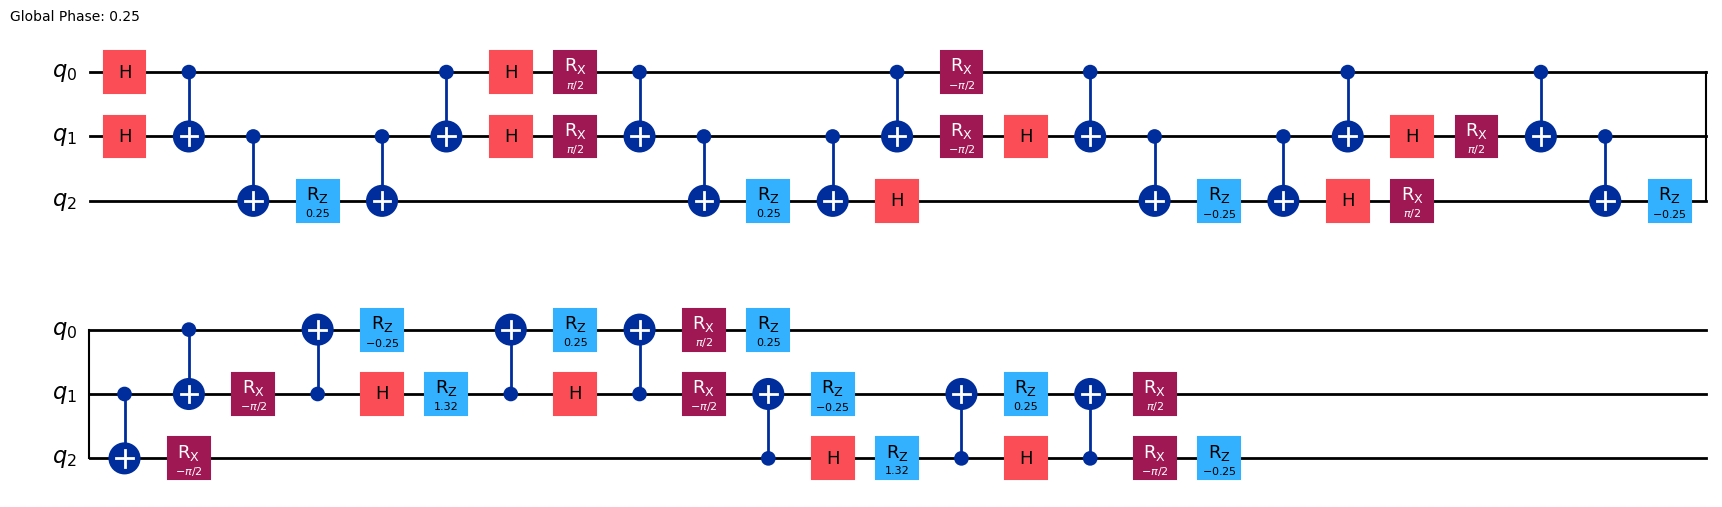

In [3]:
qr_1 = QuantumRegister(3, 'q')
qc_1 = QuantumCircuit(qr_1)

theta = 1/8
qc_1 = fredkin_unitary_new(qc_1, qr_1, theta, 0, 1, 2)
qc_1.draw('mpl')

In [4]:
optimized_qc_1 = transpile(qc_1, optimization_level = 3)
print(qc_1.depth())
print(optimized_qc_1.depth())

43
28


In [5]:
#Domain wall and Nee state quantum circuit:
def domain_wall_circuit(N):
    qr = QuantumRegister(N,'q')
    qc = QuantumCircuit(qr)
    for i in range(N):
        if i >= N//2:
            qc.x(qr[i])
    return qc

def neel_state_circuit(N):
    qr = QuantumRegister(N,'q')
    qc = QuantumCircuit(qr)
    for i in range(N):
        if i%2 == 1:
            qc.x(qr[i])
    return qc

In [6]:
#Generate time evolution circuits for the initial domain wall state and Neel state
def generate_time_evolution_circuits_new(N, T, dt, barrier=True):

    nt = int(T/dt)

    qc_list = []
    qc_depth_list = []
        
    for it in range(nt):
        start_time = time.time()
        
        
        qr = QuantumRegister(N, 'q')
        #cr = ClassicalRegister(N, 'c')
        qc = QuantumCircuit(qr)  
            


        #
        # Domain-wall initial state '00..0011..11' (first half 'up', second half 'down')
        #
        for i in range(N):
             if i >= N//2:
                qc.x(qr[i])             
        #
        # Neel's initial state 01010101...01
        #
        #for i in range(N):
        #     if i%2 == 1:
        #         qc.x(qr[i])            
            

        if(barrier): qc.barrier()

        for _ in range(it+1):

            qc = fredkinbd_new(qc, qr, -dt/2, 0, N-1)
            for n in range(N):
                if n%3 == 0:
                    if n <= (N-3):
                        fredkin_unitary_new(qc, qr, -dt/8, n, n+1, n+2)
            for n in range(N):
                if n%3 == 1:
                    if n <= (N-3):
                        fredkin_unitary_new(qc, qr, -dt/8, n, n+1, n+2)
            for n in range(N):
                if n%3 == 2:
                    if n <= (N-3):
                        fredkin_unitary_new(qc, qr, -dt/8, n, n+1, n+2)
            
            #if(barrier): qc.barrier()


        qc_list.append(qc)
        qc_depth_list.append(qc.depth())
    
    
        print(f"{it}-th iteration running time: {(time.time() - start_time)} seconds. Circuit Depth: {qc.depth()}.")
    
    return qc_list, qc_depth_list


In [7]:
# This function calculates the statevector from time evolution circuits                        
def evolved_statevector(qc_list):
    
    state_vector_List = []
    
    for i in range(len(qc_list)):
        start_time = time.time()

        state_vec = Statevector(qc_list[i])
        state_vector_List.append(state_vec)

        #print(f"{i}-th iteration running time: {(time.time() - start_time)} seconds.")
        
    
    return state_vector_List

#This function calculates the reduced density matrix from the previously determined statevector
def evolved_reudced_density_matrix(state_vec_list, site_B):
    
    reduced_density_mat_list = []
    
    for i in range(len(state_vec_list)):
        start_time = time.time()

        reduced_density_matrix_i = partial_trace(state_vec_list[i],site_B)
        reduced_density_mat_list.append(reduced_density_matrix_i)

        #print(f"{i}-th iteration running time: {(time.time() - start_time)} seconds.")
        
    
    return reduced_density_mat_list

#This function calculates the von Neumann entropy associated with the previously determined reduced density matrices
def evolved_vN_entropy(red_den_mat_list):
    
    vN_entropy_list = []
    
    for i in range(len(red_den_mat_list)):
        start_time = time.time()

        vN_entropy_i = entropy(red_den_mat_list[i], base=2)
        vN_entropy_list.append(vN_entropy_i)

        #print(f"{i}-th iteration running time: {(time.time() - start_time)} seconds.")
        
    
    return vN_entropy_list

#This function calculates the Renyi entropy associated with the previously determined reduced density matrices
def evolved_Renyi_entropy(red_den_mat_list):
    
    purity_list = []
    Renyi_entropy_list = []
    
    for i in range(len(red_den_mat_list)):
        start_time = time.time()

        purity_i = purity(red_den_mat_list[i])
        Renyi_entropy_i = - np.log(purity_i)
        purity_list.append(purity_i)
        Renyi_entropy_list.append(Renyi_entropy_i)

        #print(f"{i}-th iteration running time: {(time.time() - start_time)} seconds.")
        
    
    return Renyi_entropy_list, purity_list

#This function calculates the expectation value of a specific observable
def computeExpectation(qc_list, obs):
    
    estimator = Estimator()
    expList = []
    
    #obs_list = [obs for _ in range(len(qc_list))]
    #expList = estimator.run(qc_list, obs_list, shots = None).result().values
    
    
    for i in range(len(qc_list)):
        start_time = time.time()

        expval = estimator.run(qc_list[i], obs, shots = None).result().values[0]
        #print(type(expval))
        expList.append(expval) 


        #print(f"{i}-th iteration running time: {(time.time() - start_time)} seconds.")
        
    
    return expList

In [8]:
N = 12
dt = 0.1
T = 10.0
start_time = time.time()
qc_list, depth_list = generate_time_evolution_circuits_new(N, T, dt, barrier=True)
print(f"Total running time: {(time.time() - start_time)} seconds.")

0-th iteration running time: 0.007039785385131836 seconds. Circuit Depth: 133.
1-th iteration running time: 0.012969732284545898 seconds. Circuit Depth: 262.
2-th iteration running time: 0.021087646484375 seconds. Circuit Depth: 391.
3-th iteration running time: 0.024186134338378906 seconds. Circuit Depth: 511.
4-th iteration running time: 0.02999281883239746 seconds. Circuit Depth: 631.
5-th iteration running time: 0.03597068786621094 seconds. Circuit Depth: 751.
6-th iteration running time: 0.042150020599365234 seconds. Circuit Depth: 871.
7-th iteration running time: 0.04788923263549805 seconds. Circuit Depth: 991.
8-th iteration running time: 0.05353188514709473 seconds. Circuit Depth: 1111.
9-th iteration running time: 0.06344223022460938 seconds. Circuit Depth: 1231.
10-th iteration running time: 0.06691384315490723 seconds. Circuit Depth: 1351.
11-th iteration running time: 0.07050085067749023 seconds. Circuit Depth: 1471.
12-th iteration running time: 0.07617855072021484 second

In [8]:
optimized_qc_list = []
optimized_qc_depth_list = []
for circuit in qc_list:
    optimized_qc = transpile(circuit, optimization_level = 3)
    optimized_qc_list.append(optimized_qc)
    optimized_qc_depth_list.append(optimized_qc.depth())

In [10]:
print(depth_list)
print(optimized_qc_depth_list)

[133, 262, 391, 511, 631, 751, 871, 991, 1111, 1231, 1351, 1471, 1591, 1711, 1831, 1951, 2071, 2191, 2311, 2431, 2551, 2671, 2791, 2911, 3031]
[71, 134, 197, 259, 321, 383, 445, 507, 569, 631, 693, 755, 817, 879, 941, 1003, 1065, 1127, 1189, 1251, 1313, 1375, 1437, 1499, 1561]


In [11]:
#evolved statevectors from initial Domain wall state
start_time = time.time()
state_vec_list = evolved_statevector(optimized_qc_list)
print(f"Total running time: {(time.time() - start_time)} seconds.")

Total running time: 4.598625659942627 seconds.


In [9]:
domain_wall_statevector = Statevector(domain_wall_circuit(N))

In [10]:
ovlap_list = []
for i in range(len(qc_list)):
    evolved_state = Statevector(qc_list[i])
    ovlap = domain_wall_statevector.inner(evolved_state)
    ovlapsq = abs(ovlap)**2
    ovlap_list.append(ovlapsq)    

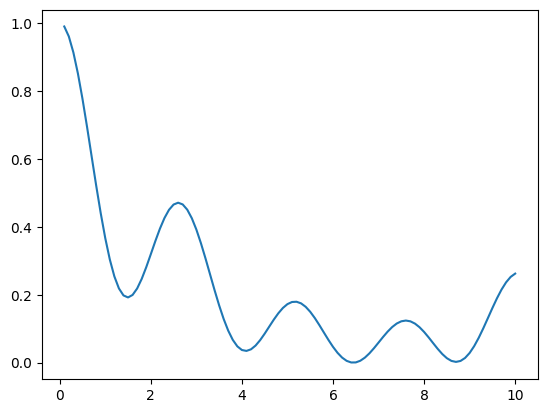

In [11]:
tlist = [dt*(i+1) for i in range(len(qc_list))]
plt.plot(tlist, ovlap_list)

In [33]:
obs_list = []
for i in range(N):
    obs_i = "I"*i + "Z" + "I"*(N-i-1)
    obs_list.append(obs_i)
print(obs_list)

coeff_list = []
for i in range(N):
    if i < N//2:
        coeff = (1/N)*(-0.5)
        coeff_list.append(coeff)
    if i >= N/2:
        coeff = (1/N)*(0.5)
        coeff_list.append(coeff)
print(coeff_list)

['ZIIIIIIIIIII', 'IZIIIIIIIIII', 'IIZIIIIIIIII', 'IIIZIIIIIIII', 'IIIIZIIIIIII', 'IIIIIZIIIIII', 'IIIIIIZIIIII', 'IIIIIIIZIIII', 'IIIIIIIIZIII', 'IIIIIIIIIZII', 'IIIIIIIIIIZI', 'IIIIIIIIIIIZ']
[-0.041666666666666664, -0.041666666666666664, -0.041666666666666664, -0.041666666666666664, -0.041666666666666664, -0.041666666666666664, 0.041666666666666664, 0.041666666666666664, 0.041666666666666664, 0.041666666666666664, 0.041666666666666664, 0.041666666666666664]


In [34]:
observable = SparsePauliOp(obs_list, coeffs=coeff_list)

In [35]:
options = {
    "run_options": {"shots": 1000}
}
estimator = Estimator_aer(options=options)

pubs = [(qc_i, observable) for qc_i in qc_list]  # Creating PUBs: (circuit, observable)
job = estimator.run(pubs)
result = job.result()

In [36]:
exp_val_t = []
for i in range(len(result)):
    expectation_value = result[i].data.evs  # Extracting the expectation value
    exp_val_t.append(expectation_value)

In [47]:
#QuSpin result up to t = 50 with dt = 0.1
tlist_quspin = [0.1*(i+1) for i in range(500)]
domainwall_observable_N12_t50_dt0p1 = [0.4983409547143197, 0.4934544401738295, 0.4856061414281495, 0.47521879228310404, 0.46284383263580325, 0.4491250706856128, 0.4347572608229011, 0.42044278988222483, 0.4068496380396951, 0.39457347188846836, 0.38410619372589777, 0.3758125914434378, 0.36991599433670813, 0.366493123503167, 0.36547769744361314, 0.36667185745283704, 0.36976413154956345, 0.37435245501607856, 0.379970687526472, 0.38611707914242677, 0.39228320670525396, 0.39798200088892516, 0.4027735956999897, 0.40628785222635244, 0.408242543553834, 0.4084563514057922, 0.40685603185882246, 0.40347736751636765, 0.39845983754878445, 0.3920352938344315, 0.38451130785504306, 0.3762502163858006, 0.36764520704700177, 0.3590950113333968, 0.3509788838882621, 0.3436335257372183, 0.3373334542051013, 0.33227604711663794, 0.3285721209586566, 0.32624247873168405, 0.3252204241373744, 0.32535982398840674, 0.326447943475207, 0.3282220027786119, 0.3303882210891972, 0.3326420275119929, 0.3346881212858943, 0.33625914438764193, 0.3371318735891877, 0.3371400320632305, 0.3361830498375973, 0.3342303567529974, 0.33132106120797145, 0.32755914293818034, 0.3231045571040577, 0.31816089668389125, 0.3129604752246133, 0.3077478561343613, 0.30276295273784626, 0.2982248436440967, 0.29431738498296794, 0.2911775569848232, 0.28888726805347137, 0.28746907377671893, 0.28688597611210304, 0.2870451770366017, 0.2878053981024085, 0.28898716473208613, 0.29038530604735485, 0.2917828422931299, 0.2929654175416306, 0.2937354723954074, 0.29392542212755307, 0.293409191741344, 0.29211154605339773, 0.290014732414085, 0.287162027264869, 0.28365785513168024, 0.2796642455661839, 0.27539352718106097, 0.27109734152293924, 0.26705229703353106, 0.2635428654924833, 0.26084242618565245, 0.2591936497161451, 0.2587896388993859, 0.2597573628721475, 0.2621448946325926, 0.2659137701157199, 0.27093742933213316, 0.277006202803121, 0.2838387186463891, 0.2910989938122039, 0.2984179118483977, 0.30541735071599213, 0.3117349647197277, 0.3170475781491423, 0.32109131937298474, 0.3236769878551452, 0.32469965229656184, 0.3241420579675872, 0.32207200086986376, 0.31863433619002435, 0.31403867420540366, 0.30854404624437076, 0.30244188968371155, 0.29603862149963633, 0.28963888063000676, 0.28353026731452247, 0.2779701414316266, 0.27317480365416824, 0.2693112016637489, 0.2664911904714086, 0.2647683258914937, 0.26413716437721646, 0.2645350534597379, 0.2658463961804482, 0.26790933660893723, 0.2705247287040662, 0.27346711770623156, 0.27649729576833737, 0.2793758163719968, 0.28187669610575694, 0.28380042865270755, 0.2849854095621178, 0.28531693601412395, 0.28473310404634133, 0.28322716308662566, 0.28084617839710224, 0.2776861623204521, 0.27388412842288656, 0.2696077650804092, 0.26504359100646635, 0.2603845302818051, 0.25581782698204303, 0.2515141198324846, 0.24761833508053782, 0.24424285595291892, 0.24146321560414064, 0.239316360232399, 0.237801356862744, 0.2368822855011477, 0.23649295994092523, 0.23654306167969807, 0.2369252401018902, 0.2375227216420718, 0.23821697516908155, 0.23889499760377503, 0.2394558135103817, 0.23981582827770023, 0.23991274040933225, 0.23970780675942555, 0.23918636423694462, 0.23835663691250286, 0.23724698832578733, 0.2359019014179003, 0.23437706802697633, 0.2327340330258324, 0.2310348560325698, 0.22933722365101492, 0.22769037205737522, 0.2261320746670435, 0.2246868283766133, 0.22336525185472145, 0.22216460621028433, 0.22107027313896144, 0.22005798291145814, 0.21909657204974597, 0.21815106030309292, 0.21718585743303032, 0.216167931110348, 0.21506977965906682, 0.21387205440369178, 0.21256566899951101, 0.2111532256560899, 0.2096495919632138, 0.2080814883237599, 0.2064860024876814, 0.2049080357587527, 0.20339679874172878, 0.2020015991560244, 0.20076728095900667, 0.19972976148442573, 0.1989121523442552, 0.19832192747368915, 0.19794951415793427, 0.19776853707422204, 0.19773775838602126, 0.19780455358007187, 0.1979095717815761, 0.19799207870919633, 0.1979953928746293, 0.19787181461664188, 0.1975865152371611, 0.19711999024856577, 0.1964688666415818, 0.1956450621027095, 0.1946734943279802, 0.1935887028610776, 0.19243085221259582, 0.19124162080868906, 0.19006044418906637, 0.18892148260111388, 0.18785154180393543, 0.1868690165520756, 0.18598377559205959, 0.1851977889389214, 0.18450622972580344, 0.18389877145902464, 0.18336084384758528, 0.1828746935322212, 0.1824201999176969, 0.18197549762958462, 0.18151753390404302, 0.18102272504750672, 0.18046786323648206, 0.17983136579486012, 0.17909486579000006, 0.17824503474174203, 0.1772754283821869, 0.176188076743229, 0.17499451716111064, 0.173716001332328, 0.17238269340476864, 0.17103180337856888, 0.16970474912710914, 0.16844358712961688, 0.1672870724948778, 0.1662667831724049, 0.16540375903534732, 0.16470606087959871, 0.16416755409654726, 0.1637680818408675, 0.16347503334613905, 0.16324615691003522, 0.16303333445110307, 0.16278694102538419, 0.16246036698875077, 0.16201428375085467, 0.16142028056826652, 0.160663578757808, 0.15974462762448294, 0.15867948978431978, 0.15749902107398955, 0.1562469341436881, 0.15497690149422022, 0.1537489031373547, 0.15262505863663184, 0.15166520624831675, 0.150922505724617, 0.1504393467254443, 0.1502438401516495, 0.15034715170593732, 0.1507419015837025, 0.15140179825013822, 0.15228259707398634, 0.15332437907863855, 0.15445503819669631, 0.15559475768356607, 0.15666116043677222, 0.15757474669519775, 0.15826419662846203, 0.15867112114679313, 0.15875389276017016, 0.1584902743974718, 0.15787867735444655, 0.15693800589101603, 0.15570616996287537, 0.15423745473713535, 0.15259901474367743, 0.15086680533468555, 0.14912127346137516, 0.14744310744784012, 0.1459092989887919, 0.14458970958864487, 0.14354426787033558, 0.14282086202002103, 0.1424539390636888, 0.14246378278200322, 0.14285641525056905, 0.14362405158391978, 0.14474603064699687, 0.14619014321080226, 0.14791428066744416, 0.1498683302528951, 0.1519962459589428, 0.15423822787190922, 0.15653294680565896, 0.15881975596078743, 0.1610408366959375, 0.1631432305746286, 0.16508071348566317, 0.16681546859732704, 0.16831951237131348, 0.1695758218932953, 0.1705791036707211, 0.17133613643089124, 0.17186561703214231, 0.1721974435699855, 0.17237138691454978, 0.17243513365024907, 0.17244172977513883, 0.17244651269839656, 0.17250368316396575, 0.17266273032971718, 0.17296497255333895, 0.173440503858797, 0.1741058338801988, 0.17496247312017704, 0.17599664607105708, 0.17718021760674693, 0.17847280310054076, 0.17982491329171374, 0.18118187576879313, 0.18248819008644013, 0.18369192421149028, 0.18474875298130922, 0.1856252759236109, 0.18630132793269572, 0.18677110278978346, 0.1870430335761184, 0.18713850095632717, 0.18708955538597363, 0.18693592961040667, 0.18672167380953053, 0.18649176227706105, 0.18628899743347538, 0.18615147895842354, 0.18611082176176935, 0.18619120819721885, 0.1864092604525256, 0.18677463096096703, 0.18729114215620998, 0.18795826832621948, 0.18877274346643225, 0.18973009696578688, 0.1908259568848173, 0.19205700936153391, 0.19342155279201048, 0.19491962898930565, 0.19655274585107635, 0.19832322649107317, 0.20023323142287108, 0.2022835089052389, 0.20447194028130533, 0.2067919668275268, 0.20923101359916926, 0.21176906085941563, 0.2143775473919665, 0.21701881180560822, 0.2196462766848651, 0.2222055471680817, 0.2246365261660147, 0.22687654561898551, 0.22886438682660443, 0.23054492910492463, 0.23187404478117146, 0.23282327020977278, 0.23338374422679406, 0.23356892791702957, 0.23341570478686186, 0.23298360118249672, 0.23235204752244246, 0.23161580012240782, 0.23087883688964528, 0.23024720464179213, 0.22982141206975712, 0.22968901773690964, 0.2299180520751935, 0.23055183899728038, 0.2316056561801711, 0.2330655080112108, 0.23488909924903856, 0.2370089090321709, 0.2393370912483436, 0.24177178317284573, 0.2442043008500337, 0.24652664396282123, 0.2486387276066323, 0.25045480187488917, 0.2519086068988882, 0.2529569319077863, 0.2535813901842435, 0.25378837393576803, 0.25360729999332654, 0.2530873856328243, 0.25229329265512734, 0.25130003955818947, 0.250187602891488, 0.24903561103372193, 0.24791848236360786, 0.2469012842324204, 0.2460365004770976, 0.24536180498578142, 0.24489885728107916, 0.2446530707401206, 0.24461425884123705, 0.24475803979949076, 0.24504787182458376, 0.24543759432075946, 0.24587435793976517, 0.2463018321993618, 0.24666357876754083, 0.24690646939840166, 0.24698401068482148, 0.24685941675644862, 0.24650825133538234, 0.24592044877272712, 0.24510152637024774, 0.24407282279095183, 0.24287064283935328, 0.2415442575593289, 0.24015279727796324, 0.2387611772774076, 0.2374353014446472, 0.23623688644923174, 0.23521832457361486, 0.23441804467442368, 0.23385682773828892, 0.23353548030593563, 0.23343416578927043, 0.2335135473612332, 0.23371772042632372, 0.23397872707109446, 0.23422227204983187, 0.23437412261485216, 0.234366592250299, 0.23414449374241184, 0.23367000344581085, 0.2329259993190112, 0.23191760409198248, 0.23067185858504863, 0.22923564227009663, 0.2276721233380017, 0.22605613880418862, 0.22446896499665125, 0.22299293855017416, 0.2217063357912193, 0.22067882959447027, 0.21996773689360166, 0.2196151665659092, 0.21964609231779175, 0.22006731817417524, 0.2208672775189285, 0.22201660567799697, 0.22346944095135407, 0.2251654274667968, 0.22703240336822605, 0.228989750775427, 0.23095235548259452, 0.23283507566757058, 0.23455755604530115, 0.23604915662031054, 0.2372537049865618, 0.2381337393564345, 0.23867389562523936, 0.23888311196942125, 0.23879538080138027, 0.23846886802752063, 0.23798333695343088, 0.23743594877114782, 0.23693565070259426, 0.23659649261458032, 0.23653031947593534, 0.23683935830467714, 0.23760924533012528, 0.23890301744366144, 0.24075652228774302, 0.24317558956264823, 0.24613516320759188, 0.2495804346076539, 0.25342985739040763, 0.25757978106298196, 0.26191032781924856, 0.2662920643979238, 0.2705929937163528, 0.27468540824682053, 0.2784522025066515, 0.28179232515999775, 0.28462514914512155, 0.28689363753289676, 0.2885662715951809, 0.28963777711647676, 0.2901287309188337, 0.29008415215413985, 0.2895711866656188, 0.288675985274799, 0.2874998673452078, 0.286154858159727, 0.2847586991034898, 0.28342945638725664, 0.2822798957990862, 0.28141184221268223, 0.2809107943886676, 0.28084110715757243, 0.28124207353295666, 0.28212522976609433, 0.2834731615234586, 0.28524000867146404, 0.2873537541216741]
domainwall_observable_N20_t50_dt0p1 = [0.49900457282859206, 0.49607266410429773, 0.4913636848568895, 0.48513127536986267, 0.4777062995814848, 0.46947504241139376, 0.4608543564938898, 0.45226567392999323, 0.4441097828262201, 0.4367440831406465, 0.43046371625680085, 0.42548755492089235, 0.42194959673453925, 0.4198958744066431, 0.4192866191392886, 0.4200031159060155, 0.4218584818808162, 0.42461147886713996, 0.4279824237163835, 0.4316702680959011, 0.43536996050309257, 0.43878926264929047, 0.44166425923928404, 0.4437728721824626, 0.4449457713611416, 0.44507417230854546, 0.44411413530134364, 0.4420871364875956, 0.43907687019725306, 0.4352224557753248, 0.4307084481776823, 0.42575226955850476, 0.42058986671606374, 0.41546053484968354, 0.4105919142621656, 0.40618615338138997, 0.40240813783552487, 0.3993765197495164, 0.3971580605456856, 0.39576554661059293, 0.39515927493846836, 0.3952518589964802, 0.39591589335006855, 0.3969938528286605, 0.3983094951790152, 0.3996799857780775, 0.4009279645039137, 0.401892820576936, 0.40244052222983095, 0.40247145610871854, 0.401925859510607, 0.4007865717411622, 0.3990789849400875, 0.3968682356295709, 0.3942538408727124, 0.39136214023331284, 0.38833704747800635, 0.38532973325815073, 0.38248794051432267, 0.3799456680250061, 0.37781393753999226, 0.37617328431505215, 0.3750684834792187, 0.374505855377816, 0.3744532967961691, 0.37484298005386807, 0.3755764675819619, 0.37653182333641155, 0.3775721778963157, 0.37855512939733466, 0.3793423393467068, 0.37980870675141176, 0.3798505671870465, 0.37939245416436695, 0.3783920667503271, 0.37684319982181624, 0.3747765045257452, 0.3722580529585548, 0.369385782329106, 0.3662839913831581, 0.3630961572964643, 0.3599764347113601, 0.3570802873746714, 0.3545547808080139, 0.3525291224934154, 0.351106063453268, 0.3503547615664349, 0.3503056450561676, 0.35094770190260816, 0.352228461588295, 0.35405674064276577, 0.3563080101010141, 0.35883203253751056, 0.3614622313204514, 0.36402611563708953, 0.36635600701480386, 0.3682993043634904, 0.3697275842071204, 0.3705439515626008, 0.37068821885278497, 0.37013967513174245, 0.36891739462840867, 0.36707820329855767, 0.36471256067586943, 0.3619387141902232, 0.35889554331302603, 0.35573453613956124, 0.35261133981981396, 0.3496773083572433, 0.3470714452561653, 0.3449131097217429, 0.34329582487796984, 0.34228249203751215, 0.3419022708812935, 0.34214932507292467, 0.34298355134734954, 0.34433330596570616, 0.3461000189806683, 0.3481644525939183, 0.35039422802114095, 0.3526521313108933, 0.35480462814386665, 0.35672998371282266, 0.35832540414590236, 0.35951269158687105, 0.36024202966781266, 0.36049367678340455, 0.3602775236083256, 0.3596306488351917, 0.35861316405332117, 0.3573027594140903, 0.3557884361242697, 0.35416393631726906, 0.35252135839108156, 0.35094538474593473, 0.3495084607563249, 0.3482671617567148, 0.34725988085898857, 0.34650587397516736, 0.3460056153347218, 0.3457423492299694, 0.34568467086726035, 0.34578992844986683, 0.3460082070544848, 0.34628663056168757, 0.34657370079453964, 0.34682338512909816, 0.34699866881950653, 0.3470743103910436, 0.34703858121417613, 0.34689383518890826, 0.34665583959142576, 0.3463518981885338, 0.34601790396851984, 0.34569456014705424, 0.34542309253195796, 0.34524083293815044, 0.34517707401905356, 0.3452495767413057, 0.3454620538862307, 0.3458028624769372, 0.34624502508293675, 0.3467475773598293, 0.3472581205346933, 0.3477163553166452, 0.34805829760659035, 0.3482208322512064, 0.3481462505013904, 0.3477864373463495, 0.347106420881197, 0.34608705975171694, 0.34472671830421764, 0.3430418547295734, 0.34106651907016594, 0.33885082122088866, 0.33645848171737924, 0.3339636195135996, 0.33144696154995545, 0.32899167965121207, 0.3266790721221834, 0.3245843109638078, 0.3227724711333074, 0.32129504562628797, 0.32018712919194, 0.3194654242297751, 0.3191271853208094, 0.3191501749604784, 0.31949365402280067, 0.3201003784307309, 0.3208995208957688, 0.3218103860069773, 0.3227467409359602, 0.3236215449567872, 0.3243518310167793, 0.32486347366440643, 0.3250955714418166, 0.32500417981130736, 0.32456515386500095, 0.3237758989627466, 0.3226558817341313, 0.3212458221389129, 0.31960556672012636, 0.3178107295224724, 0.3159482746557894, 0.31411129627536166, 0.3123933203400137, 0.3108825005824739, 0.3096561024696661, 0.3087756593689971, 0.30828314334409945, 0.30819842101886213, 0.30851816827480866, 0.309216304758939, 0.3102458910471424, 0.311542319528805, 0.3130275357850292, 0.3146149595144323, 0.31621473872835876, 0.3177389697609379, 0.3191065461919895, 0.3202473559363852, 0.32110561875885707, 0.321642236409628, 0.3218361049513882, 0.32168440603232756, 0.32120194610775166, 0.32041964849438087, 0.31938232432154523, 0.31814585887640884, 0.31677395456241747, 0.315334575469006, 0.3138962446747352, 0.31252435486378105, 0.3112776640499232, 0.31020515737052445, 0.30934345787905004, 0.3087149587384946, 0.30832682209354484, 0.3081709443983154, 0.3082249253832371, 0.3084540026738575, 0.308813833625602, 0.3092539293067991, 0.30972148227431745, 0.3101652883051753, 0.31053944860877214, 0.31080655586233014, 0.3109401134294062, 0.31092600737306114, 0.3107629374315349, 0.31046180627186104, 0.31004415598880436, 0.309539817903555, 0.3089839993289418, 0.30841406507160063, 0.3078662810812296, 0.3073727746588996, 0.30695893391608386, 0.3066414238273799, 0.3064269425839042, 0.30631178485555055, 0.306282221849281, 0.3063156544432098, 0.3063824470023109, 0.3064483070342398, 0.30647704082727656, 0.3064334890754566, 0.30628643104227365, 0.30601124303946076, 0.30559210867828573, 0.30502360548716945, 0.30431153474258993, 0.30347291664870757, 0.30253513738366233, 0.30153430244926155, 0.30051291563788385, 0.29951705803129086, 0.2985932808602943, 0.2977854456108603, 0.2971317427027473, 0.2966620973400289, 0.29639613124772135, 0.2963417974629494, 0.2964947487344741, 0.2968384450300147, 0.2973449577952837, 0.2979763917873262, 0.29868682109501, 0.2994246236590191, 0.30013509563469226, 0.3007632295922451, 0.30125654490464565, 0.3015678615435041, 0.3016579081694597, 0.30149765203222456, 0.30107023383332737, 0.3003723888519973, 0.29941524047592794, 0.2982243677166947, 0.29683907697182316, 0.295310850825804, 0.2937010011807023, 0.2920776161168758, 0.29051195324478146, 0.28907448942206215, 0.2878308800599905, 0.28683810447331953, 0.2861410726730041, 0.28576994239695375, 0.2857383449160641, 0.2860426490723284, 0.2866623121985675, 0.2875612824000659, 0.28869033763196245, 0.28999018057502146, 0.2913950600965759, 0.2928366632327399, 0.29424801668870165, 0.29556715200940226, 0.2967403202000277, 0.29772458498954985, 0.29848967416901906, 0.2990190209430235, 0.2993099783302107, 0.2993732367462222, 0.29923151644152035, 0.29891764166298085, 0.2984721318852749, 0.29794046688618003, 0.29737019628294686, 0.29680806958808337, 0.29629735891212683, 0.29587553231209607, 0.29557241116761346, 0.29540891048930845, 0.2953964185290975, 0.2955368244962338, 0.29582315462971115, 0.2962407319429139, 0.29676873818154464, 0.297382031706846, 0.29805306454901137, 0.2987537464047759, 0.2994571216154475, 0.3001387542093988, 0.3007777518006085, 0.3013573969004261, 0.30186538970225296, 0.3022937362568207, 0.30263833815743135, 0.30289835388048203, 0.30307540855514586, 0.3031727297947377, 0.3031942842042435, 0.30314398387304226, 0.3030250254394935, 0.3028394161674192, 0.3025877311503448, 0.30226913214349144, 0.3018816606759378, 0.3014227957925445, 0.3008902409109864, 0.3002828770067082, 0.2996017938943634, 0.29885129160086976, 0.29803973348061324, 0.29718013471898597, 0.2962903856012943, 0.2953930378405776, 0.2945146217812143, 0.2936845081086481, 0.29293337436611305, 0.2922913783973587, 0.2917861727144362, 0.29144091206235906, 0.2912724094030172, 0.29128958359667295, 0.2914923176031275, 0.291870812876448, 0.2924054883073129, 0.2930674349854995, 0.2938194047849072, 0.2946172835451816, 0.2954119791280537, 0.2961516401505956, 0.29678411105509983, 0.29725952132526967, 0.2975328993788069, 0.2975666941321916, 0.2973330798704587, 0.2968159145861763, 0.2960122211148187, 0.2949330673736656, 0.2936037396999054, 0.2920631335074744, 0.29036232836201686, 0.2885623681528166, 0.28673132727887896, 0.28494080492029433, 0.2832620448143051, 0.2817619207505024, 0.28049905248629636, 0.2795203191086322, 0.27885801571670293, 0.2785278561526484, 0.2785279634614891, 0.278838916963817, 0.2794248476015271, 0.28023549906399514, 0.28120910780171665, 0.28227590545923037, 0.2833620154831643, 0.28439350243329825, 0.28530033659355253, 0.2860200550961101, 0.28650093034618745, 0.28670449331647097, 0.2866072999255648, 0.2862018706533941, 0.28549677509820076, 0.2845158734361994, 0.28329676527518394, 0.2818885328675994, 0.2803488994847902, 0.27874095388055187, 0.27712961656788676, 0.2755780410646335, 0.27414415119207497, 0.27287751210002104, 0.271816716834655, 0.27098744192752144, 0.2704012858934307, 0.27005545615834253, 0.26993331629917855, 0.2700057507050044, 0.27023325214410016, 0.27056859316103027, 0.27095990785377355, 0.2713539884339561, 0.27169959190932486, 0.2719505559969619, 0.27206853884561116, 0.27202522260370404, 0.27180385433301674, 0.2714000372269372, 0.2708217286460368, 0.270088447350363, 0.2692297387332576, 0.268282991973778, 0.2672907447024569, 0.2662976465921898, 0.26534728058163887, 0.2644790565277973, 0.26372539459117306, 0.26310940291652374, 0.26264322562655645, 0.262327193651728, 0.26214985489020354, 0.26208889553275433, 0.2621128962036032, 0.2621838006816836, 0.2622599172970005, 0.26229922899597735, 0.2622627617060963, 0.2621177545077026, 0.2618403898020988, 0.26141787573161546, 0.26084972335668666, 0.260148122937853, 0.25933739166597797, 0.2584525336328867, 0.25753701635203397, 0.25663992213173115, 0.2558126736058408, 0.2551055585671041, 0.2545642890551372, 0.2542268237274285, 0.25412066215235496, 0.2542607867908254, 0.2546483855470659, 0.2552704376421976, 0.25610019114808974, 0.25709850486819424, 0.2582159734723866, 0.2593957059778072, 0.2605765867932131, 0.2616968183034583, 0.26269752655157247, 0.26352620840995794, 0.26413981015770777, 0.2645072528774869, 0.26461125763069365, 0.2644493699541207, 0.26403413502587075, 0.2633924276586281, 0.2625639909786353, 0.2615992807133938, 0.2605567459099645, 0.25949970034609765, 0.2584929518559304]

Text(0.5, 1.0, 'N = 12, Domain-wall observable, initial DW state')

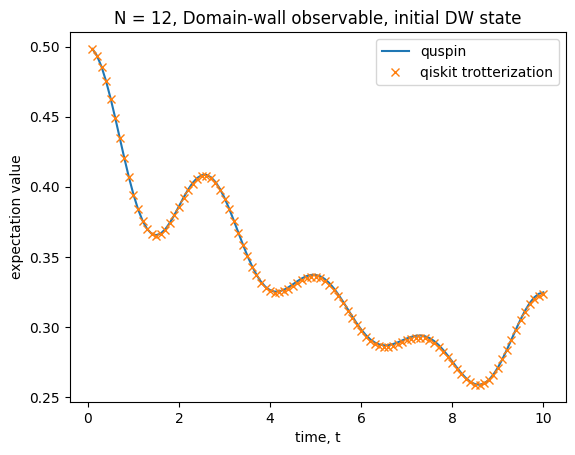

In [46]:
plt.plot(tlist_quspin[:100], domainwall_observable_N12_t50_dt0p1[:100], label = 'quspin')
plt.plot(tlist,exp_val_t,'x', label = 'qiskit trotterization')
plt.xlabel('time, t')
plt.ylabel('expectation value')
plt.legend(loc = 'upper right')
plt.title('N = 12, Domain-wall observable, initial DW state')